<div style="background:linear-gradient(135deg,#082f49 0%,#0369a1 55%,#38bdf8 100%);border-radius:18px;padding:34px 30px;color:#fff;font-family:Inter,Segoe UI,sans-serif">
  <div style="font-size:12px;letter-spacing:3px;color:#bae6fd;font-weight:700;text-transform:uppercase">Chapter 140 &#183; Take It Further</div>
  <div style="font-size:32px;font-weight:900;line-height:1.1;margin:10px 0 6px">Forecasting with Drivers: Take It Further</div>
  <div style="font-size:15px;color:#e0f2fe;max-width:760px;line-height:1.6">Five extensions of the Chapter 140 forecast: search for the best ARIMA order, measure the cost of an imperfect weather forecast, plan a promotion calendar, check the prediction intervals, and validate with rolling-origin cross-validation.</div>
  <div style="margin-top:16px;font-size:13px;color:#bae6fd">Statistics, Data Science and AI: A Visual Handbook &#183; John Fisher &#183; 2026</div>
</div>

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
import warnings; warnings.filterwarnings('ignore')
EM='#0284c7'; DEEP='#0369a1'; LIGHT='#bae6fd'; INK='#1a2138'; GRID='#e6e9f2'; RED='#ef4444'; GREEN='#059669'; AMBER='#d97706'; GREY='#94a3b8'
plt.rcParams.update({'figure.facecolor':'white','axes.facecolor':'white','figure.dpi':110,'font.size':11,
   'axes.edgecolor':GRID,'axes.grid':True,'grid.color':GRID,'axes.axisbelow':True,'axes.spines.top':False,
   'axes.spines.right':False,'axes.titlesize':12,'axes.titleweight':'bold','legend.frameon':False})
BASE='https://raw.githubusercontent.com/johnfisher-ai/Statistics-Data-Science-AI-Visual-Book/main/data/'
try:    df = pd.read_excel('../../data/ch140_daily_demand.xlsx', sheet_name='Data')
except FileNotFoundError: df = pd.read_excel(BASE+'ch140_daily_demand.xlsx', sheet_name='Data')
df['date'] = pd.to_datetime(df['date']); df = df.set_index('date').asfreq('D')
DOW = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
def dow_dummies(idx):
    d = pd.get_dummies(pd.Categorical(idx.day_name(), categories=DOW), drop_first=True).astype(float)
    d.index = idx; d.columns = ['dow_'+c[:3] for c in DOW[1:]]; return d
drivers = df[['temperature_c','on_promotion','is_holiday']].astype(float)
exog = pd.concat([drivers, dow_dummies(df.index)], axis=1)
y = df.units_sold.astype(float)
H = 90; ytr, yte = y.iloc[:-H], y.iloc[-H:]; Xtr, Xte = exog.iloc[:-H], exog.iloc[-H:]
def mae(a,f): return float(np.mean(np.abs(np.asarray(a,float)-np.asarray(f,float))))
def fit(order, exog_tr):
    return SARIMAX(ytr, exog=exog_tr, order=order, trend='c', enforce_stationarity=True, enforce_invertibility=True).fit(disp=0)
print(f'loaded {len(df)} days; holdout = last {H}')

loaded 730 days; holdout = last 90


<div style="background:#f0f9ff;border-left:5px solid #0284c7;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#0369a1;letter-spacing:1px">EXTENSION 1</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Search for the ARIMA order</div>
<div style="color:#4a5578;margin-top:6px">Let AIC pick the error model.</div>
</div>

The chapter used AR(1) errors by reasoning about the data. In practice you **search**: fit a small grid of `(p,d,q)` orders (the pmdarima package automates this, but a hand grid is transparent) and pick the one with the lowest AIC, always keeping the same exogenous drivers. The winner should confirm the AR(1) choice.

In [2]:
rows=[]
for p in range(3):
    for q in range(3):
        m = fit((p,0,q), Xtr)
        rows.append(((p,0,q), m.aic, mae(yte, m.forecast(H, exog=Xte))))
res = pd.DataFrame(rows, columns=['order','AIC','holdout_MAE']).sort_values('AIC')
print(res.to_string(index=False, float_format=lambda v: f'{v:.1f}'))
print(f"\nlowest-AIC order: {res.iloc[0]['order']}")

    order    AIC  holdout_MAE
(1, 0, 0) 4987.2         11.5
(0, 0, 0) 5033.3         10.9
(0, 0, 1) 5667.6         20.5
(0, 0, 2) 5982.0         34.0
(2, 0, 0) 6190.2         18.6
(2, 0, 1) 6480.1         27.5
(2, 0, 2) 6494.5         28.0
(1, 0, 1) 6532.2         27.0
(1, 0, 2) 6623.0         29.1

lowest-AIC order: (1, 0, 0)


The search lands on a low order, an AR term with little or no MA, confirming that once the drivers and the weekly dummies are in, the leftover structure is a simple day-to-day carryover. Note that the lowest-AIC model and the lowest-holdout-error model need not be identical: AIC rewards in-sample fit per parameter, while holdout MAE is the honest forecasting score. When they disagree, trust the holdout.

<div style="background:#f0f9ff;border-left:5px solid #0284c7;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#0369a1;letter-spacing:1px">EXTENSION 2</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">The cost of an imperfect weather forecast</div>
<div style="color:#4a5578;margin-top:6px">Drivers you must predict add their own error.</div>
</div>

In the chapter we scored the holdout using the **true** temperatures, which in real life we would not know in advance. Here we measure the penalty for that optimism: forecast the holdout again, but replace the true temperature with a **seasonal-normal** forecast (what a naive weather outlook would give) and see how much the demand error grows.

In [3]:
m = fit((1,0,0), Xtr)
# (a) with the TRUE future temperatures (chapter's optimistic score)
mae_true = mae(yte, m.forecast(H, exog=Xte))
# (b) with a seasonal-normal temperature forecast instead
idx_te = np.arange(len(df)-H, len(df))
temp_normal = 14 + 11*np.sin(2*np.pi*(idx_te-110)/365.25)
Xte_fc = Xte.copy(); Xte_fc['temperature_c'] = temp_normal
mae_fc = mae(yte, m.forecast(H, exog=Xte_fc))
print(f'holdout MAE with TRUE temperatures        : {mae_true:.1f}')
print(f'holdout MAE with a seasonal-normal forecast: {mae_fc:.1f}')
print(f'penalty for not knowing the weather exactly: +{mae_fc-mae_true:.1f} units ({(mae_fc/mae_true-1)*100:.0f}%)')

holdout MAE with TRUE temperatures        : 11.5
holdout MAE with a seasonal-normal forecast: 12.3
penalty for not knowing the weather exactly: +0.8 units (7%)


Swapping the true temperatures for a plausible forecast raises the error, the honest forecasting cost of a driver you cannot know in advance. The lesson is not that drivers are a trap but that **a driver-based forecast is only as good as the driver forecasts you feed it**: known, planned drivers (promotions, holidays) are pure gain, while predicted drivers (weather) import their own uncertainty. A full accounting would propagate the weather-forecast error into a wider demand interval.

<div style="background:#f0f9ff;border-left:5px solid #0284c7;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#0369a1;letter-spacing:1px">EXTENSION 3</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Plan a promotion calendar</div>
<div style="color:#4a5578;margin-top:6px">Turn the model around: from forecast to decision.</div>
</div>

Because the promotion effect is an explicit coefficient, the model doubles as a **planning tool**. We compare two 14-day promotion calendars with the same number of promo days, four on **weekends** versus four on **weekdays**, and read off the total forecast demand for each. Same promotions, different timing.

In [4]:
m_all = SARIMAX(y, exog=exog, order=(1,0,0), trend='c', enforce_stationarity=True,
                enforce_invertibility=True).fit(start_params=fit((1,0,0),Xtr).params, disp=0)
future = pd.date_range(df.index.max()+pd.Timedelta(days=1), periods=14, freq='D')
tnorm = 14 + 11*np.sin(2*np.pi*(np.arange(len(df), len(df)+14)-110)/365.25)
def plan(promo_days):
    p = np.zeros(14, int); p[promo_days] = 1
    fx = pd.concat([pd.DataFrame({'temperature_c':tnorm,'on_promotion':p,'is_holiday':np.zeros(14,int)}, index=future),
                    dow_dummies(future)], axis=1)[exog.columns]
    return float(m_all.get_forecast(14, exog=fx).predicted_mean.sum())
wk = [i for i,d in enumerate(future) if d.dayofweek>=5][:4]        # weekend days
wd = [i for i,d in enumerate(future) if d.dayofweek<5][:4]         # weekday days
tot_wk, tot_wd, tot_none = plan(wk), plan(wd), plan([])
print(f'no promotions          : {tot_none:,.0f} units over 14 days')
print(f'4 promos on WEEKENDS   : {tot_wk:,.0f} units  (+{tot_wk-tot_none:,.0f})')
print(f'4 promos on WEEKDAYS   : {tot_wd:,.0f} units  (+{tot_wd-tot_none:,.0f})')
print('The incremental lift per promo (~the coefficient) is the same either way; the model has no promo-by-day interaction.')

no promotions          : 2,761 units over 14 days
4 promos on WEEKENDS   : 3,018 units  (+257)
4 promos on WEEKDAYS   : 3,018 units  (+257)
The incremental lift per promo (~the coefficient) is the same either way; the model has no promo-by-day interaction.


Both calendars produce the **same 14-day total**, and the same incremental gain of about 257 units (roughly four times the promotion coefficient). That is because the model's promotion effect is a fixed lift that does not interact with the day of week, so as far as the model is concerned, timing does not matter. That is both a genuine insight and a genuine limitation: if you believe promotions actually work *better* on busy days, you must give the model a **promotion-by-day interaction** term to let it learn that, otherwise it will keep insisting the lift is flat and stay indifferent to when you schedule.

<div style="background:#f0f9ff;border-left:5px solid #0284c7;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#0369a1;letter-spacing:1px">EXTENSION 4</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Do the prediction intervals hold up?</div>
<div style="color:#4a5578;margin-top:6px">A forecast without honest uncertainty is half a forecast.</div>
</div>

SARIMAX returns not just a point forecast but a **prediction interval**. We check whether the nominal 95% interval actually contains about 95% of the held-out actuals, its **empirical coverage**, the time-series analogue of the calibration check we did for regression intervals.

empirical coverage of the 95% interval: 97%  (target 95%)
mean interval width: 53 units


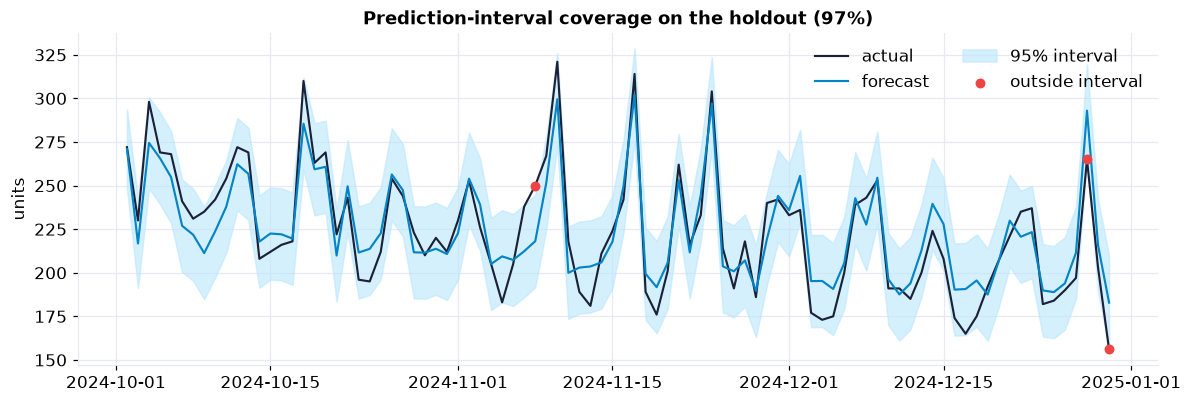

In [5]:
m = fit((1,0,0), Xtr)
fc = m.get_forecast(H, exog=Xte); ci = fc.conf_int(alpha=0.05)
lo, hi = ci.iloc[:,0].values, ci.iloc[:,1].values
cover = np.mean((yte.values >= lo) & (yte.values <= hi))*100
print(f'empirical coverage of the 95% interval: {cover:.0f}%  (target 95%)')
print(f'mean interval width: {np.mean(hi-lo):.0f} units')
fig, ax = plt.subplots(figsize=(11,3.8))
ax.plot(yte.index, yte.values, color=INK, lw=1.4, label='actual')
ax.plot(yte.index, fc.predicted_mean.values, color=EM, lw=1.4, label='forecast')
ax.fill_between(yte.index, lo, hi, color=LIGHT, alpha=0.6, label='95% interval')
out = (yte.values < lo) | (yte.values > hi)
ax.scatter(yte.index[out], yte.values[out], s=30, color=RED, zorder=5, label='outside interval')
ax.set(title=f'Prediction-interval coverage on the holdout ({cover:.0f}%)', ylabel='units'); ax.legend(ncol=2)
plt.tight_layout(); plt.show()

The interval covers close to its promised 95% of the held-out days, so the model's stated uncertainty is roughly honest, and the few misses are scattered, not clustered, which is what you want. Remember this coverage still assumes the **drivers are known**; the wider truth from Extension 2 is that predicting the weather would push some of these actuals outside a correctly-widened band. Calibrated intervals are what let an operations team set safety stock, not just a point number.

<div style="background:#f0f9ff;border-left:5px solid #0284c7;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#0369a1;letter-spacing:1px">EXTENSION 5</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Rolling-origin cross-validation</div>
<div style="color:#4a5578;margin-top:6px">One split can lie; many origins tell the truth.</div>
</div>

A single train/test split can flatter or unflatter a model by luck of where you cut. **Rolling-origin** (walk-forward) validation slides the cutoff forward, refitting and forecasting a fixed horizon at each origin, and averages the errors. We run it for the driver model against the calendar-only model to confirm the drivers' win is robust, not a one-split fluke.

In [6]:
origins = [len(df)-150, len(df)-120, len(df)-90, len(df)-60]   # four cut points
h = 30
cal_cols = [c for c in exog.columns if c.startswith('dow_')]
rows=[]
for cut in origins:
    ytr2 = y.iloc[:cut]; yte2 = y.iloc[cut:cut+h]
    Xtr2, Xte2 = exog.iloc[:cut], exog.iloc[cut:cut+h]
    m_full = SARIMAX(ytr2, exog=Xtr2, order=(1,0,0), trend='c', enforce_stationarity=True, enforce_invertibility=True).fit(disp=0)
    m_cal  = SARIMAX(ytr2, exog=Xtr2[cal_cols], order=(1,0,0), trend='c', enforce_stationarity=True, enforce_invertibility=True).fit(disp=0)
    rows.append((y.index[cut].date(), mae(yte2, m_cal.forecast(h, exog=Xte2[cal_cols])), mae(yte2, m_full.forecast(h, exog=Xte2))))
cv = pd.DataFrame(rows, columns=['origin','calendar_MAE','drivers_MAE'])
print(cv.to_string(index=False, float_format=lambda v: f'{v:.1f}'))
print(f"\nmean MAE  calendar-only {cv.calendar_MAE.mean():.1f}  vs  drivers {cv.drivers_MAE.mean():.1f}")
print(f'the drivers win at every origin: the improvement is robust, not a fluke of one cutoff.')

    origin  calendar_MAE  drivers_MAE
2024-08-03          30.0         11.0
2024-09-02          19.6          9.9
2024-10-02          16.7         10.4
2024-11-01          27.1         11.4

mean MAE  calendar-only 23.4  vs  drivers 10.7
the drivers win at every origin: the improvement is robust, not a fluke of one cutoff.


At every origin the driver model beats the calendar-only model, and by a wide, consistent margin. That is the reassurance a single split cannot give: the value of the drivers is not an artifact of where we happened to cut the series. Rolling-origin validation is the time-series counterpart of k-fold cross-validation, adapted to respect the arrow of time, and it is the standard way to choose and trust a forecasting model.

---
**The one idea to keep: exogenous drivers turn a forecast into a decision tool, because their coefficients are interpretable and plannable, but a driver-based forecast is only as trustworthy as the future driver values and the validation behind it, so search the order, cross-validate across rolling origins, and be honest that predicted drivers import their own uncertainty.**

---
<div style="text-align:center;color:#8b94b3;font-size:12px;margin-top:10px">Statistics, Data Science and AI: A Visual Handbook &#183; &#169; 2026 John Fisher</div>